Using device: cuda
Tesla T4

Total Vietnamese food classes: 30

 Validation entries: 2515
 Test entries: 5040

Number of validation samples: 2515
Number of test samples: 5040

STARTING EVALUATIONS

EVALUATION ON VALIDATION SET

Model loaded from: /kaggle/working/best_vit_vn30food_model.pth
Epoch: 10
Train Loss: 0.6978 | Train Acc: 99.00%
Val Loss: 0.9826 | Val Acc: 89.61%

EVALUATING MODEL ON VALIDATION SET

Overall Validation Accuracy: 89.70%

Classification Report (Validation Set):
                  precision    recall  f1-score   support

        banh_beo      0.822     0.923     0.870        65
    banh_bot_loc      0.864     0.781     0.820        73
        banh_can      0.896     0.920     0.908        75
       banh_canh      0.841     0.763     0.800        97
      banh_chung      0.868     0.920     0.893        50
       banh_cuon      0.896     0.904     0.900       114
        banh_duc      0.797     0.712     0.752        66
        banh_gio      0.896     0.938     0.91

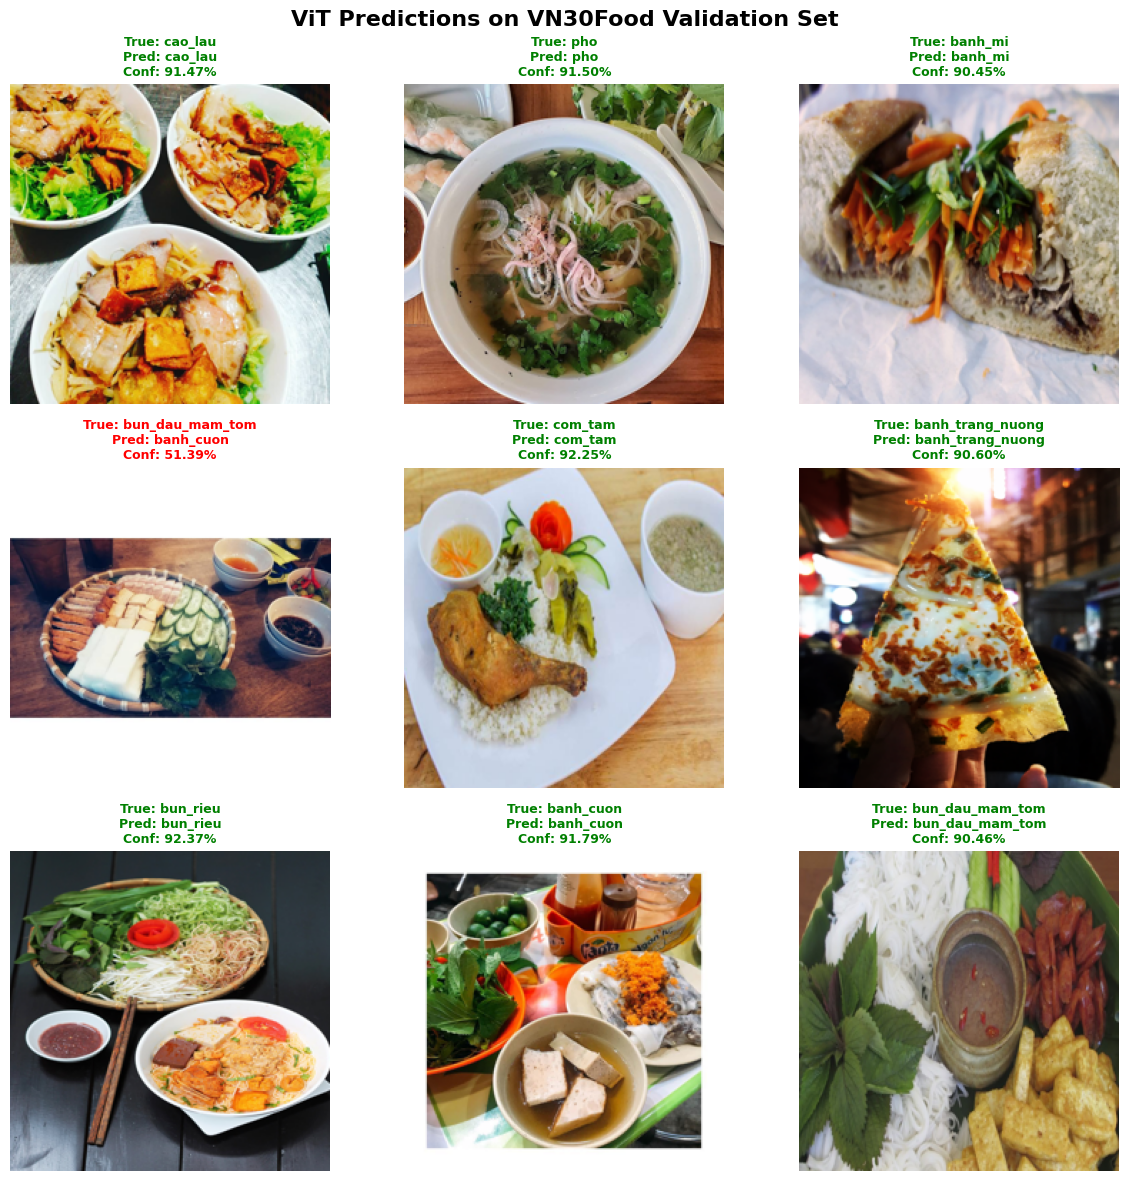


Test Set Predictions:

Model loaded from: /kaggle/working/best_vit_vn30food_model.pth
Epoch: 10
Train Loss: 0.6978 | Train Acc: 99.00%
Val Loss: 0.9826 | Val Acc: 89.61%


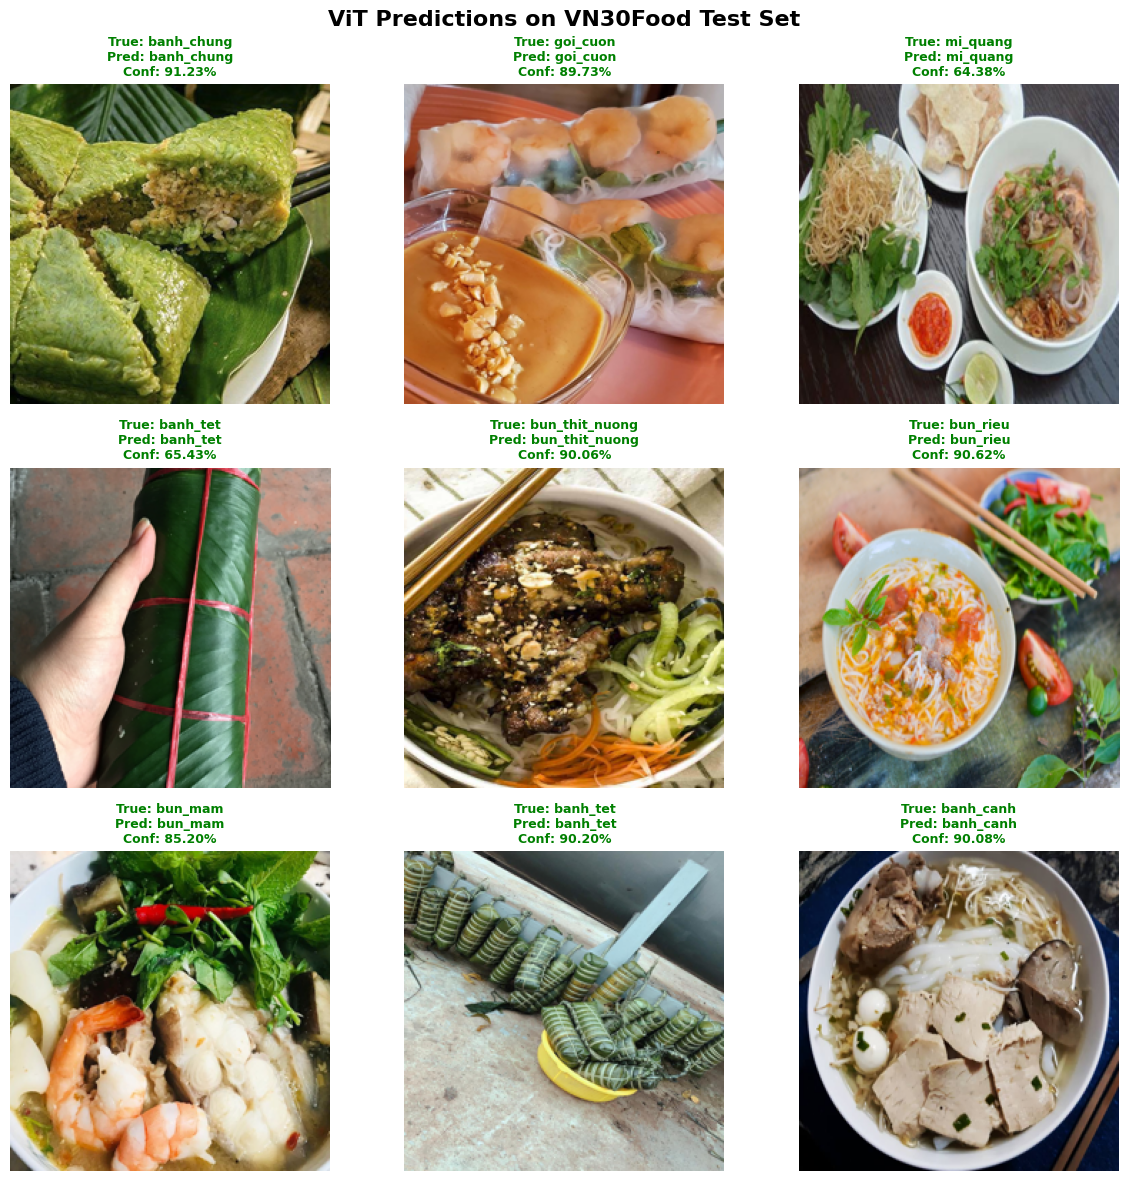


PLOTTING CONFUSION MATRICES
Showing confusion matrix for top 15 classes (out of 30)

Validation Set:

Model loaded from: /kaggle/working/best_vit_vn30food_model.pth
Epoch: 10
Train Loss: 0.6978 | Train Acc: 99.00%
Val Loss: 0.9826 | Val Acc: 89.61%


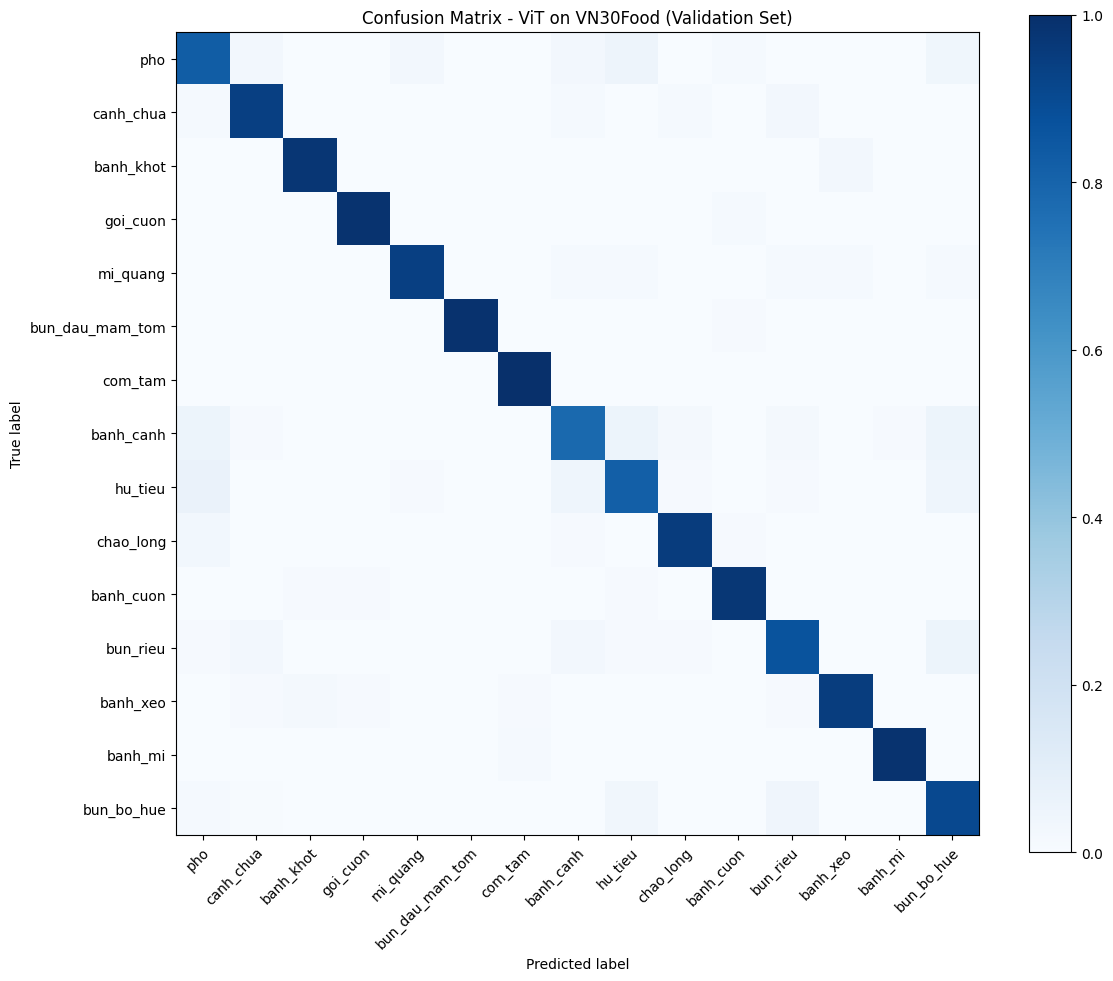


Test Set:

Model loaded from: /kaggle/working/best_vit_vn30food_model.pth
Epoch: 10
Train Loss: 0.6978 | Train Acc: 99.00%
Val Loss: 0.9826 | Val Acc: 89.61%


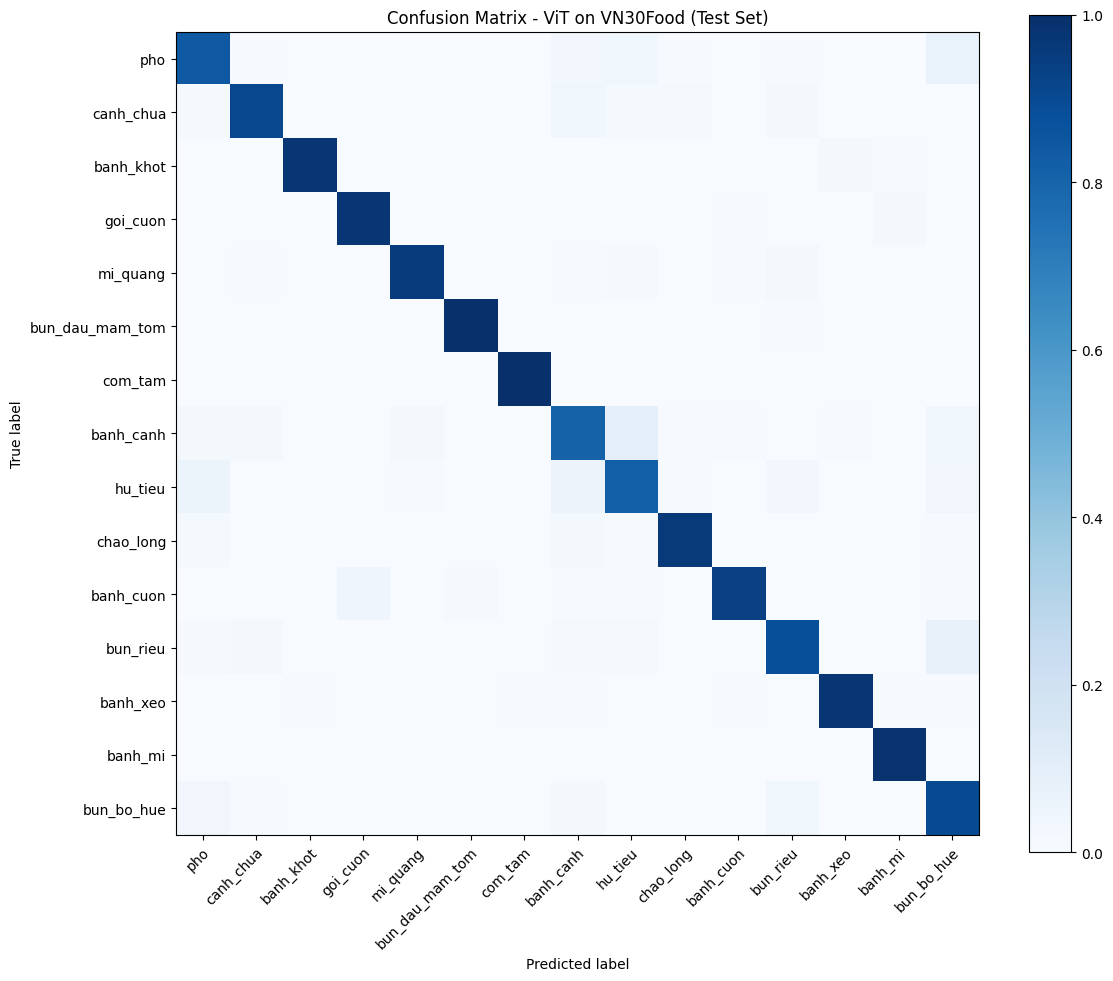

In [4]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import json
import os
import unicodedata
from torchvision.transforms import InterpolationMode
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

os.environ["WANDB_DISABLED"] = "true"

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

# ============================================================
# PATHS CONFIGURATION
# ============================================================
VNF_DIR = "/kaggle/input/dataset-for-nutridish-project/Model_Training/datasets/30vnfoods/Images"
BASE_DIR = os.path.dirname(VNF_DIR)

# Read Vietnamese food classes
with open(os.path.join(BASE_DIR, "class_mapping.json")) as f:
    vn_classes_map = json.load(f)

vn_classes = list(vn_classes_map.keys())
NUM_CLASSES = len(vn_classes)
CLASS_TO_INDEX = {c: i for i, c in enumerate(vn_classes)}
print(f"\nTotal Vietnamese food classes: {NUM_CLASSES}")

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def normalize_name(name):
    """Remove accents and normalize class names"""
    name = unicodedata.normalize("NFD", name)
    name = "".join(ch for ch in name if unicodedata.category(ch) != "Mn")
    name = name.strip().lower().replace(" ", "_")
    return name

def list_images(base_dir, subset, vn_classes):
    """List all valid images in Vietnamese food dataset"""
    paths, labels = [], []
    subset_dir = os.path.join(base_dir, subset)
    
    if not os.path.exists(subset_dir):
        print(f"⚠ Directory not found: {subset_dir}")
        return paths, labels
    
    for class_name in os.listdir(subset_dir):
        class_dir = os.path.join(subset_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        
        class_key = normalize_name(class_name)
        if class_key not in vn_classes:
            continue
        
        class_label = vn_classes.index(class_key)
        
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                full_path = os.path.join(class_dir, fname)
                paths.append(full_path)
                labels.append(class_label)
    
    return paths, labels
val_paths, val_labels = list_images(VNF_DIR, "Validate", vn_classes)
test_paths, test_labels = list_images(VNF_DIR, "Test", vn_classes)

print(f"\n Validation entries: {len(val_paths)}")
print(f" Test entries: {len(test_paths)}")

class VNFoodDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"\n⚠ Error loading {img_path}: {e}")
            image = Image.new('RGB', (224, 224), color='white')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# ============================================================
# DATA TRANSFORMATIONS
# ============================================================
val_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Create datasets
val_dataset = VNFoodDataset(val_paths, val_labels, transform=val_transform)
test_dataset = VNFoodDataset(test_paths, test_labels, transform=val_transform)

# Create data loaders
batch_size = 64

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

print(f"\nNumber of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

# ============================================================
# MODEL LOADING FUNCTION - FIXED
# ============================================================
def load_model(model_path='/kaggle/working/best_vit_vn30food_model.pth'):
    """Load trained ViT model from checkpoint"""
    # Load the saved state
    checkpoint = torch.load(model_path, map_location=device)
    num_classes = checkpoint['num_classes']
    
    # Initialize the model architecture
    model = torchvision.models.vit_b_16(weights=None)
    
    # Modify classifier head - PHẢI KHỚP VỚI ARCHITECTURE KHI TRAIN
    in_features = model.heads.head.in_features
    model.heads.head = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 512),  # Hidden layer
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)   # Output layer
    )
    
    # Load weights
    model.load_state_dict(checkpoint['model_state_dict'])
    class_list = checkpoint['class_list']
    
    model = model.to(device)
    model.eval()
    
    print(f"\nModel loaded from: {model_path}")
    if 'epoch' in checkpoint:
        print(f"Epoch: {checkpoint['epoch']}")
        print(f"Train Loss: {checkpoint['train_loss']:.4f} | Train Acc: {checkpoint['train_acc']:.2f}%")
        print(f"Val Loss: {checkpoint['val_loss']:.4f} | Val Acc: {checkpoint['val_acc']:.2f}%")
    
    return model, class_list

# ============================================================
# EVALUATION FUNCTION
# ============================================================
def evaluate_model(use_test_set=False):
    """Evaluate model with detailed metrics"""
    model, class_list = load_model()
    
    eval_loader = test_loader if use_test_set else val_loader
    eval_name = "Test" if use_test_set else "Validation"
    
    print("\n" + "="*60)
    print(f"EVALUATING MODEL ON {eval_name.upper()} SET")
    print("="*60)
    
    all_predictions = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for X, y in eval_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    # Overall accuracy
    accuracy = 100 * (all_predictions == all_labels).sum() / len(all_labels)
    print(f"\nOverall {eval_name} Accuracy: {accuracy:.2f}%")
    
    # Classification report
    report = classification_report(
        all_labels, 
        all_predictions, 
        target_names=class_list,
        digits=3,
        zero_division=0
    )
    print(f"\nClassification Report ({eval_name} Set):")
    print(report)
    
    # Per-class accuracy
    cm = confusion_matrix(all_labels, all_predictions)
    per_class_accuracy = cm.diagonal() / (cm.sum(axis=1) + 1e-10)
    
    # Get best and worst performing classes
    class_accuracies = list(zip(class_list, per_class_accuracy))
    class_accuracies.sort(key=lambda x: x[1], reverse=True)
    
    print("\nTop 10 Best Performing Classes:")
    for class_name, acc in class_accuracies[:10]:
        print(f"  {class_name}: {acc*100:.2f}%")
    
    print("\nTop 10 Worst Performing Classes:")
    for class_name, acc in class_accuracies[-10:]:
        print(f"  {class_name}: {acc*100:.2f}%")
    
    return accuracy, all_predictions, all_labels

# ============================================================
# VISUALIZE PREDICTIONS
# ============================================================
def visualize_predictions(num_samples=9, use_test_set=False):
    """Visualize model predictions on random images"""
    model, class_list = load_model()
    
    eval_dataset = test_dataset if use_test_set else val_dataset
    eval_name = "Test" if use_test_set else "Validation"
    
    # Get random samples
    indices = random.sample(range(len(eval_dataset)), min(num_samples, len(eval_dataset)))
    
    rows = int(np.sqrt(num_samples))
    cols = int(np.ceil(num_samples / rows))
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten() if num_samples > 1 else [axes]
    
    model.eval()
    with torch.no_grad():
        for idx, ax in enumerate(axes):
            if idx >= len(indices):
                ax.axis('off')
                continue
            
            # Get image and true label
            img, true_label = eval_dataset[indices[idx]]
            
            # Make prediction
            img_batch = img.unsqueeze(0).to(device)
            outputs = model(img_batch)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            pred_prob, pred_idx = torch.max(probs, 1)
            
            # Denormalize image
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            img_display = img * std + mean
            img_display = transforms.ToPILImage()(img_display.clamp(0, 1))
            
            # Display
            ax.imshow(img_display)
            
            true_class = class_list[true_label]
            pred_class = class_list[pred_idx.item()]
            confidence = pred_prob.item()
            
            # Color code: green if correct, red if incorrect
            color = 'green' if true_label == pred_idx.item() else 'red'
            
            title = f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.2%}"
            ax.set_title(title, fontsize=9, color=color, fontweight='bold')
            ax.axis('off')
    
    plt.suptitle(f'ViT Predictions on VN30Food {eval_name} Set', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/vit_predictions_{eval_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================
def plot_confusion_matrix(num_classes_to_show=None, use_test_set=False):
    """Plot confusion matrix for the model"""
    model, class_list = load_model()
    
    eval_loader = test_loader if use_test_set else val_loader
    eval_name = "Test" if use_test_set else "Validation"
    
    all_predictions = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for X, y in eval_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    # If too many classes, show only subset
    if num_classes_to_show and num_classes_to_show < len(class_list):
        # Find most common classes
        unique, counts = np.unique(all_labels, return_counts=True)
        top_classes = unique[np.argsort(counts)[-num_classes_to_show:]]
        
        # Filter confusion matrix
        mask = np.isin(all_labels, top_classes)
        filtered_labels = [all_labels[i] for i in range(len(all_labels)) if mask[i]]
        filtered_preds = [all_predictions[i] for i in range(len(all_predictions)) if mask[i]]
        
        cm = confusion_matrix(filtered_labels, filtered_preds, labels=top_classes)
        display_classes = [class_list[i] for i in top_classes]
    else:
        display_classes = class_list
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    
    # Set ticks
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=display_classes,
           yticklabels=display_classes,
           title=f'Confusion Matrix - ViT on VN30Food ({eval_name} Set)',
           ylabel='True label',
           xlabel='Predicted label')
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/vit_confusion_matrix_{eval_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================
# ATTENTION VISUALIZATION
# ============================================================
def visualize_attention_maps(image_idx=None, num_heads_to_show=4):
    """Visualize attention maps from the last transformer layer"""
    model, class_list = load_model()
    
    # Get a random image if not specified
    if image_idx is None:
        image_idx = random.randint(0, len(val_dataset)-1)
    
    img, true_label = val_dataset[image_idx]
    
    # Forward pass with attention extraction
    model.eval()
    img_batch = img.unsqueeze(0).to(device)
    
    # Hook to capture attention weights
    attention_weights = []
    
    def get_attention_hook(module, input, output):
        # PyTorch MultiheadAttention returns (output, attention_weights) or just output
        # We need to check and handle both cases
        if isinstance(output, tuple):
            if len(output) > 1 and output[1] is not None:
                attention_weights.append(output[1])
        
    # Register hook on last encoder layer's attention
    hook = model.encoder.layers.encoder_layer_11.self_attention.register_forward_hook(get_attention_hook)
    
    with torch.no_grad():
        outputs = model(img_batch)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        pred_prob, pred_idx = torch.max(probs, 1)
    
    hook.remove()
    
    # Process attention weights
    if attention_weights and attention_weights[0] is not None:
        attn = attention_weights[0]
        
        # Check if we have batch dimension
        if attn.dim() == 4:  # [batch, num_heads, seq_len, seq_len]
            attn = attn[0]  # Remove batch dimension
        
        # Average attention from CLS token to all patches
        cls_attention = attn[:, 0, 1:]  # [num_heads, num_patches-1]
        
        # Reshape to spatial grid
        num_patches = int(np.sqrt(cls_attention.shape[1]))
        cls_attention = cls_attention.reshape(cls_attention.shape[0], num_patches, num_patches)
        
        # Denormalize image
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_display = img * std + mean
        img_display = transforms.ToPILImage()(img_display.clamp(0, 1))
        
        # Plot
        fig = plt.figure(figsize=(16, 4))
        
        # Original image
        ax = plt.subplot(1, num_heads_to_show+1, 1)
        ax.imshow(img_display)
        ax.set_title(f"Original\nTrue: {class_list[true_label]}\n"
                    f"Pred: {class_list[pred_idx.item()]} ({pred_prob.item():.2%})",
                    fontsize=10)
        ax.axis('off')
        
        # Attention maps from different heads
        for head in range(min(num_heads_to_show, cls_attention.shape[0])):
            ax = plt.subplot(1, num_heads_to_show+1, head+2)
            
            # Resize attention map
            attn_map = cls_attention[head].cpu().numpy()
            attn_map = np.array(Image.fromarray(attn_map).resize((224, 224), Image.BICUBIC))
            
            # Overlay on image
            ax.imshow(img_display)
            ax.imshow(attn_map, cmap='jet', alpha=0.6)
            ax.set_title(f'Attention Head {head+1}', fontsize=10)
            ax.axis('off')
        
        plt.suptitle('Vision Transformer Attention Visualization', 
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('/kaggle/working/vit_attention_maps.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(" Could not extract attention weights from the model.")
        print("This is normal - attention visualization requires special model configuration.")
        print("Skipping attention visualization...")

# ============================================================
# RUN EVALUATIONS
# ============================================================
print("\n" + "="*80)
print("STARTING EVALUATIONS")
print("="*80)

# Validation set evaluation
print("\n" + "="*80)
print("EVALUATION ON VALIDATION SET")
print("="*80)
evaluate_model(use_test_set=False)

# Test set evaluation
print("\n" + "="*80)
print("EVALUATION ON TEST SET")
print("="*80)
evaluate_model(use_test_set=True)

# Visualize predictions
print("\n" + "="*60)
print("VISUALIZING PREDICTIONS")
print("="*60)
print("\nValidation Set Predictions:")
visualize_predictions(num_samples=9, use_test_set=False)
print("\nTest Set Predictions:")
visualize_predictions(num_samples=9, use_test_set=True)

# Confusion matrices
print("\n" + "="*60)
print("PLOTTING CONFUSION MATRICES")
print("="*60)
if NUM_CLASSES > 15:
    print(f"Showing confusion matrix for top 15 classes (out of {NUM_CLASSES})")
    print("\nValidation Set:")
    plot_confusion_matrix(num_classes_to_show=15, use_test_set=False)
    print("\nTest Set:")
    plot_confusion_matrix(num_classes_to_show=15, use_test_set=True)
else:
    print("\nValidation Set:")
    plot_confusion_matrix(use_test_set=False)
    print("\nTest Set:")
    plot_confusion_matrix(use_test_set=True)